<a href="https://colab.research.google.com/github/RahulRajGiri15/Dhanavardhanam__GenAI-Powered-Credit-Platform-for-MSMEs-iSPIRT-/blob/main/MSME.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [ ]:
df = pd.read_excel(r"MSME Credit Data by 30S-CR.xlsx")

In [ ]:
df.head()

,Enterprise_id,Label,Registered_capital (Ten thousand Yuan),Province,Enterprise_type,Establishment_Duration (Days),Paid_in_capital (Ten thousand Yuan),Sector,SH_num,MS_num,...,Legal_proceedings_num_3years,Legal_proceedings_num_2years,Legal_proceedings_num_1year,Filing_information_num_5years+,Filing_information_num_5years,Filing_information_num_4years,Filing_information_num_3years,Filing_information_num_2years,Filing_information_num_1years,Ratepaying_Credit_Grade_A_num
0,1,0,1200.0,Sichuan,Limited liability company (Natural person inve...,1521.0,111.5967,Construction industry,2.0,2.0,...,0,0,0,0,0,0,0,0,0,1
1,2,0,5315.0,Sichuan,Limited liability company (sole proprietorship...,1150.0,5315.0000,Construction industry,1.0,3.0,...,0,0,0,0,0,0,0,0,0,0
2,3,0,5100.0,Sichuan,Limited liability company (sole proprietorship...,1975.0,5100.0000,Construction industry,1.0,2.0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,2000.0,Jiangxi,Limited liability company (Natural person inve...,778.0,0.0000,Construction industry,2.0,2.0,...,0,0,0,0,0,0,0,0,0,0
4,5,0,5700.0,Hubei,Other joint stock limited companies (unlisted),8187.0,5033.2300,Scientific research and technology services,17.0,8.0,...,3,8,4,0,1,1,3,3,0,5


In [ ]:
df.isnull().sum()

,0
Enterprise_id,0
Label,0
Registered_capital (Ten thousand Yuan),0
Province,0
Enterprise_type,0
...,...
Filing_information_num_4years,0
Filing_information_num_3years,0
Filing_information_num_2years,0
Filing_information_num_1years,0


In [ ]:
df=df.drop("Province",inplace=True,axis=1)

In [ ]:
categorical_columns = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)
print(df_encoded.head())
print(f"Dataset shape after encoding: {df_encoded.shape}")


AttributeError: 'NoneType' object has no attribute 'select_dtypes'

In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Step 1: Data Preprocessing
# Assuming `df` is the DataFrame
X = df_encoded.drop(columns=['Label','Enterprise_id'])  # Features
y = df_encoded['Label']  # Target variable

# Handle missing values
X = X.fillna(X.median())

# Encode categorical variables (if not already done)
X = pd.get_dummies(X, drop_first=True)

# Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Step 2: Build the FNN Model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.2),  # Prevent overfitting
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 3: Train the Model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Step 4: Evaluate the Model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy}")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9253 - loss: 0.4100 - val_accuracy: 0.9524 - val_loss: 0.2088
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9207 - loss: 0.3106 - val_accuracy: 0.9524 - val_loss: 0.2061
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9465 - loss: 0.1915 - val_accuracy: 0.9414 - val_loss: 0.2059
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9535 - loss: 0.1755 - val_accuracy: 0.9414 - val_loss: 0.2097
Epoch 5/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9456 - loss: 0.1634 - val_accuracy: 0.9377 - val_loss: 0.2241
Epoch 6/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9573 - loss: 0.1287 - val_accuracy: 0.9267 - val_loss: 0.2437
Epoch 7/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9496 - loss: 0.1472 - val_accuracy: 0.9304 - val_loss: 0.2601
Epoch 8/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9570 - loss: 0.1194 - val_accuracy: 0.9341 - val_loss:

In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          17,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 78,341 (306.02 KB)

 Trainable params: 26,113 (102.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 52,228 (204.02 KB)

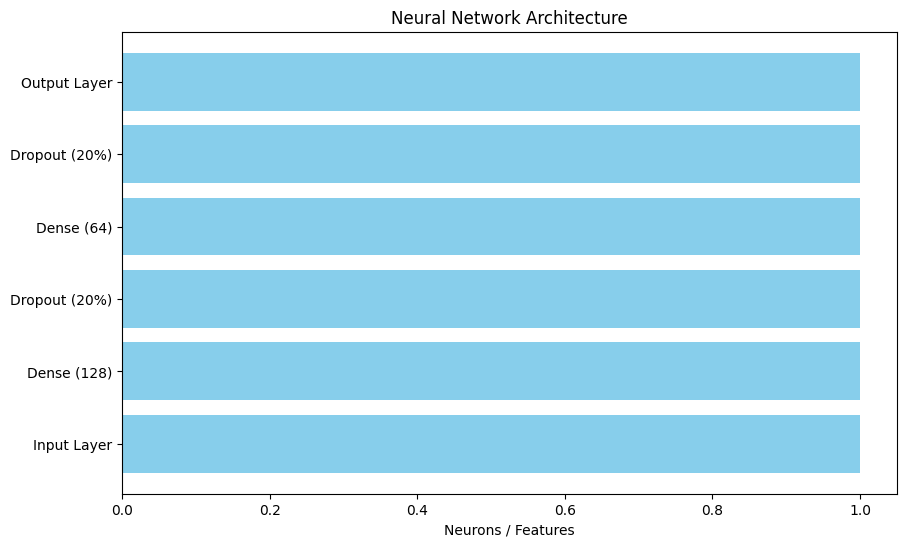

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

layers = ['Input Layer', 'Dense (128)', 'Dropout (20%)', 'Dense (64)', 'Dropout (20%)', 'Output Layer']
positions = range(len(layers))

ax.barh(positions, [1] * len(layers), color='skyblue')
ax.set_yticks(positions)
ax.set_yticklabels(layers)
ax.set_xlabel('Neurons / Features')
ax.set_title('Neural Network Architecture')
plt.show()
